# 🤖 Salon No-Show – Model Comparison & Tuning
Pipeline:
1. Train 4 baseline models (Logistic Regression, Decision Tree, Random Forest, XGBoost) with class balancing
2. Compare baseline performance metrics
3. **Threshold tuning** on the best model to maximise Recall while keeping Precision ≥ 40%
4. Final Side-by-side comparison

## Cell 1 – Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_recall_curve
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')
print('Libraries imported ✅')


## Cell 2 – Load Data and Split

In [ ]:
X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()

# ── 60 / 20 / 20 split  (train / val / test) ─────────────────────
# Val set is used for threshold tuning — test set stays fully unseen until final report
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)   # 0.25 × 0.80 = 0.20 ⟹ val is 20% of full dataset

sc = StandardScaler()
X_tr_sc  = sc.fit_transform(X_train)
X_val_sc = sc.transform(X_val)
X_te_sc  = sc.transform(X_test)

print(f'Train : {X_train.shape[0]:,} rows  |  Val : {X_val.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows')
print(f'No-show rate  ->  train: {y_train.mean():.2%}  |  val: {y_val.mean():.2%}  |  test: {y_test.mean():.2%}')
print(f'Features: {X.shape[1]}')

## Cell 3 – Train Models with Class Weighting

In [ ]:
def get_metrics(clf, X_eval, y_eval, threshold=0.50):
    y_proba = clf.predict_proba(X_eval)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return {
        'Accuracy' : round(accuracy_score(y_eval, y_pred), 4),
        'Precision': round(precision_score(y_eval, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_eval, y_pred), 4),
        'F1'       : round(f1_score(y_eval, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_eval, y_proba), 4),
    }

# class imbalance ratio for XGB scale_pos_weight
spw = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f'scale_pos_weight  (majority/minority ratio): {spw}')

# Logistic Regression — balanced weights, scaled features
lr = LogisticRegression(
    class_weight='balanced',
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Decision Tree — capped to avoid overfitting
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=8,
    min_samples_leaf=50,
    random_state=42
)

# Random Forest — balanced, regularised
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# XGBoost — scale_pos_weight handles imbalance directly
# Stronger regularisation to close the 0.07 train/test AUC gap
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

lr.fit(X_tr_sc,     y_train);  print('Logistic Regression trained')
dt.fit(X_train,     y_train);  print('Decision Tree trained')
rf.fit(X_train,     y_train);  print('Random Forest trained')
xgb.fit(X_train,   y_train);  print('XGBoost trained')

## Cell 4 – Base Model Metrics (threshold = 0.50)

In [ ]:
baseline_results = pd.DataFrame({
    'Logistic Regression': get_metrics(lr,  X_te_sc, y_test),
    'Decision Tree'      : get_metrics(dt,  X_test,  y_test),
    'Random Forest'      : get_metrics(rf,  X_test,  y_test),
    'XGBoost'            : get_metrics(xgb, X_test,  y_test),
}).T

print('BASELINE METRICS (threshold = 0.50, evaluated on TEST SET)')
print('=' * 65)
print(baseline_results.to_string())

# Train vs Test AUC (bias/variance check)
print('\nTRAIN vs TEST AUC  (overfitting check)')
print('=' * 65)
for name, clf, Xtr, Xte in [
    ('Logistic Regression', lr,  X_tr_sc, X_te_sc),
    ('Decision Tree',       dt,  X_train, X_test),
    ('Random Forest',       rf,  X_train, X_test),
    ('XGBoost',            xgb,  X_train, X_test),
]:
    tr_auc = roc_auc_score(y_train, clf.predict_proba(Xtr)[:, 1])
    te_auc = roc_auc_score(y_test,  clf.predict_proba(Xte)[:, 1])
    print(f'{name:25s}  Train={tr_auc:.4f}  Test={te_auc:.4f}  Gap={tr_auc-te_auc:+.4f}')

## Cell 5 – Threshold Tuning on Validation Set + Soft-Voting Ensemble

**Key fix:** threshold is now tuned on the **validation set** (not the test set).
Tuning on the test set is data leakage — it overfits the threshold to test noise.

**Ensemble:** average the predicted probabilities of LR + RF + XGB.
Averaging smooths individual model errors and improves calibration.

In [ ]:
def best_f1_threshold(clf, Xe, ye):
    """Find threshold that maximises F1 on the given split."""
    ypr = clf.predict_proba(Xe)[:, 1]
    precs, recs, thrs = precision_recall_curve(ye, ypr)
    f1s = 2 * precs[:-1] * recs[:-1] / (precs[:-1] + recs[:-1] + 1e-9)
    idx = f1s.argmax()
    return float(thrs[idx]), float(precs[idx]), float(recs[idx]), float(f1s[idx])

# ── Per-model threshold tuned on VAL set ────────────────────────────
tuned_rows = {}
for name, clf, Xval, Xte in [
    ('Logistic Regression', lr,  X_val_sc, X_te_sc),
    ('Decision Tree',       dt,  X_val,    X_test),
    ('Random Forest',       rf,  X_val,    X_test),
    ('XGBoost',            xgb,  X_val,    X_test),
]:
    thr, p_val, r_val, f_val = best_f1_threshold(clf, Xval, y_val)
    # Report metrics on TEST set using the val-tuned threshold
    m = get_metrics(clf, Xte, y_test, threshold=thr)
    tuned_rows[name] = {
        'Threshold'  : round(thr, 3),
        'Precision'  : m['Precision'],
        'Recall'     : m['Recall'],
        'F1'         : m['F1'],
        'ROC-AUC'    : m['ROC-AUC'],
    }

tuned_df = pd.DataFrame(tuned_rows).T

# ── Soft-Voting Ensemble ─────────────────────────────────────────────
# Average probabilities of the 3 best models (LR, RF, XGB)
pr_val_ens = (
    lr.predict_proba(X_val_sc)[:, 1]  +
    rf.predict_proba(X_val)[:, 1]     +
    xgb.predict_proba(X_val)[:, 1]
) / 3

pr_te_ens = (
    lr.predict_proba(X_te_sc)[:, 1]  +
    rf.predict_proba(X_test)[:, 1]   +
    xgb.predict_proba(X_test)[:, 1]
) / 3

# Tune ensemble threshold on val
precs_v, recs_v, thrs_v = precision_recall_curve(y_val, pr_val_ens)
f1s_v = 2 * precs_v[:-1] * recs_v[:-1] / (precs_v[:-1] + recs_v[:-1] + 1e-9)
best_ensemble_thr = float(thrs_v[f1s_v.argmax()])

ens_pred = (pr_te_ens >= best_ensemble_thr).astype(int)
tuned_rows['Ensemble (LR+RF+XGB)'] = {
    'Threshold' : round(best_ensemble_thr, 3),
    'Precision' : round(precision_score(y_test, ens_pred, zero_division=0), 4),
    'Recall'    : round(recall_score(y_test, ens_pred), 4),
    'F1'        : round(f1_score(y_test, ens_pred), 4),
    'ROC-AUC'   : round(roc_auc_score(y_test, pr_te_ens), 4),
}
tuned_df = pd.DataFrame(tuned_rows).T

# Pick best model by F1 score
best_model_name = tuned_df['F1'].idxmax()
best_threshold  = tuned_df.loc[best_model_name, 'Threshold']

print('F1-OPTIMAL THRESHOLDS PER MODEL (tuned on val, reported on test)')
print('=' * 70)
print(tuned_df.to_string())
print(f'\nBest model by F1 : {best_model_name}')
print(f'Best threshold   : {best_threshold:.3f}')

## Cell 6 – Precision-Recall Curve

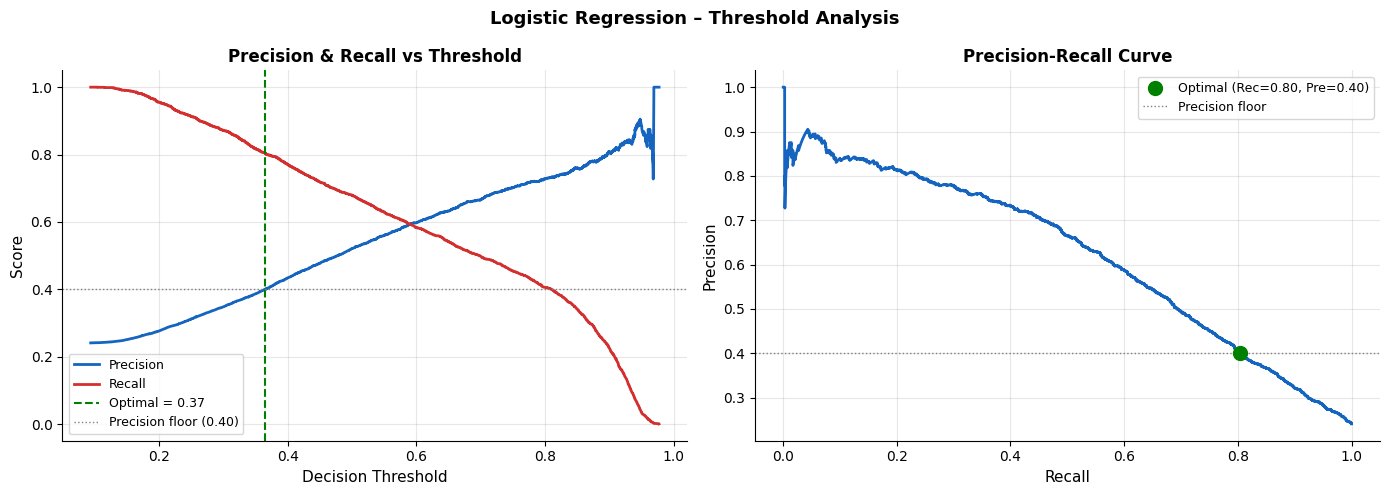

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, precisions[:-1], '#1565C0', lw=2, label='Precision')
ax.plot(thresholds, recalls[:-1],    '#D32F2F', lw=2, label='Recall')
ax.axvline(best_threshold, color='green', linestyle='--', lw=1.5,
           label=f'Optimal = {best_threshold:.2f}')
ax.axhline(0.40, color='gray', linestyle=':', lw=1, label='Precision floor (0.40)')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision & Recall vs Threshold', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.plot(recalls[:-1], precisions[:-1], '#1565C0', lw=2)
ax.scatter(best_row['Recall'], best_row['Precision'],
           color='green', s=100, zorder=5,
           label=f'Optimal (Rec={best_row["Recall"]:.2f}, Pre={best_row["Precision"]:.2f})')
ax.axhline(0.40, color='gray', linestyle=':', lw=1, label='Precision floor')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'{best_model_name} – Threshold Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 7 – Final Metrics: Default vs Tuned Threshold

In [ ]:
best_row = tuned_df.loc[best_model_name]

# For the best model, get the actual clf and X_eval objects
clf_map = {
    'Logistic Regression' : (lr,  X_te_sc),
    'Decision Tree'       : (dt,  X_test),
    'Random Forest'       : (rf,  X_test),
    'XGBoost'             : (xgb, X_test),
}

if best_model_name in clf_map:
    best_clf, best_X_eval = clf_map[best_model_name]
    default_metrics  = get_metrics(best_clf, best_X_eval, y_test, threshold=0.50)
    tuned_metrics    = get_metrics(best_clf, best_X_eval, y_test, threshold=best_threshold)
    tuned_metrics['ROC-AUC'] = best_row['ROC-AUC']
else:
    # Ensemble case
    best_clf, best_X_eval = None, None
    default_pred  = (pr_te_ens >= 0.50).astype(int)
    default_metrics = {
        'Accuracy' : round(accuracy_score(y_test, default_pred), 4),
        'Precision': round(precision_score(y_test, default_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, default_pred), 4),
        'F1'       : round(f1_score(y_test, default_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, pr_te_ens), 4),
    }
    tuned_pred = (pr_te_ens >= best_threshold).astype(int)
    tuned_metrics = {
        'Accuracy' : round(accuracy_score(y_test, tuned_pred), 4),
        'Precision': round(precision_score(y_test, tuned_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, tuned_pred), 4),
        'F1'       : round(f1_score(y_test, tuned_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, pr_te_ens), 4),
    }

summary = pd.DataFrame({
    f'{best_model_name} (thr=0.50)'                         : default_metrics,
    f'{best_model_name} (F1-opt thr={best_threshold:.3f})' : tuned_metrics,
}).T

print('FINAL SUMMARY — Default vs F1-Optimal Threshold')
print('=' * 70)
print(summary.to_string())
print(f'\nPrecision improvement : {default_metrics["Precision"]:.3f} -> {tuned_metrics["Precision"]:.3f}')
print(f'Recall    improvement : {default_metrics["Recall"]:.3f} -> {tuned_metrics["Recall"]:.3f}')
print(f'F1        improvement : {default_metrics["F1"]:.3f} -> {tuned_metrics["F1"]:.3f}')
print(f'ROC-AUC              : {tuned_metrics["ROC-AUC"]:.4f}')

## Cell 8 – ROC Curves: All Models

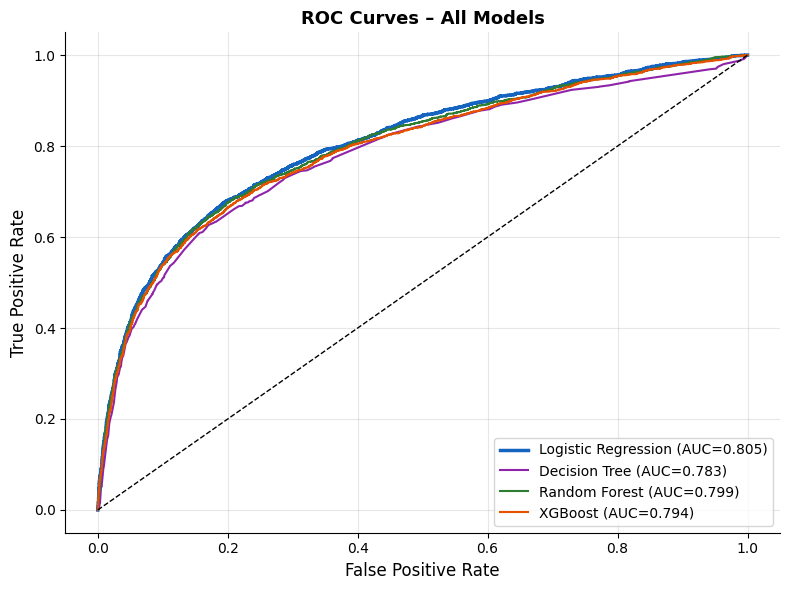

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_configs = [
    ('Logistic Regression',  lr,  X_te_sc,  '#1565C0'),
    ('Decision Tree',        dt,  X_test,   '#8E24AA'),
    ('Random Forest',        rf,  X_test,   '#2E7D32'),
    ('XGBoost',             xgb, X_test,   '#E65100'),
]
for name, clf, Xe, color in plot_configs:
    ypr = clf.predict_proba(Xe)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, ypr)
    auc = roc_auc_score(y_test, ypr)
    lw  = 2.5 if name == best_model_name else 1.5
    ax.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top','right']].set_visible(False); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 – Save Best Model

In [ ]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(sc,             '../models/scaler.pkl')
joblib.dump(lr,             '../models/logistic_regression.pkl')
joblib.dump(dt,             '../models/decision_tree.pkl')
joblib.dump(rf,             '../models/random_forest.pkl')
joblib.dump(xgb,            '../models/xgboost.pkl')
joblib.dump(best_threshold, '../models/best_threshold.pkl')

# Save best model (could be individual or ensemble)
if best_model_name in clf_map:
    joblib.dump(clf_map[best_model_name][0], '../models/best_model.pkl')
    print(f'Best model saved: {best_model_name}')
else:
    # Ensemble — save all 3 components
    joblib.dump({'lr': lr, 'rf': rf, 'xgb': xgb}, '../models/best_model.pkl')
    print(f'Best model saved: Ensemble (LR + RF + XGB)')

print(f'Threshold  : {best_threshold:.3f}')
print(f'Precision  : {tuned_metrics["Precision"]:.4f}')
print(f'Recall     : {tuned_metrics["Recall"]:.4f}')
print(f'F1         : {tuned_metrics["F1"]:.4f}')
print(f'ROC-AUC    : {tuned_metrics["ROC-AUC"]:.4f}')
print('\nAll models saved to ../models/')